<a href="https://colab.research.google.com/github/nicosepu07/desafiooo2/blob/main/desafio2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ===============================
# 1. EXTRACCIÓN DE DATOS
# ===============================

import requests
import pandas as pd

url = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/main/TelecomX_Data.json"

response = requests.get(url)
data = response.json()

df = pd.json_normalize(data)

print("Dimensiones:", df.shape)
df.head()

Dimensiones: (7267, 21)


,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


In [ ]:
# ===============================
# 2. CONOCIENDO EL DATASET
# ===============================

df.info()
df.dtypes
df.describe(include='all')
df.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   Churn                      7267 non-null   object 
 2   customer.gender            7267 non-null   object 
 3   customer.SeniorCitizen     7267 non-null   int64  
 4   customer.Partner           7267 non-null   object 
 5   customer.Dependents        7267 non-null   object 
 6   customer.tenure            7267 non-null   int64  
 7   phone.PhoneService         7267 non-null   object 
 8   phone.MultipleLines        7267 non-null   object 
 9   internet.InternetService   7267 non-null   object 
 10  internet.OnlineSecurity    7267 non-null   object 
 11  internet.OnlineBackup      7267 non-null   object 
 12  internet.DeviceProtection  7267 non-null   object 
 13  internet.TechSupport       7267 non-null   objec

Index(['customerID', 'Churn', 'customer.gender', 'customer.SeniorCitizen',
       'customer.Partner', 'customer.Dependents', 'customer.tenure',
       'phone.PhoneService', 'phone.MultipleLines', 'internet.InternetService',
       'internet.OnlineSecurity', 'internet.OnlineBackup',
       'internet.DeviceProtection', 'internet.TechSupport',
       'internet.StreamingTV', 'internet.StreamingMovies', 'account.Contract',
       'account.PaperlessBilling', 'account.PaymentMethod',
       'account.Charges.Monthly', 'account.Charges.Total'],
      dtype='object')

In [ ]:
# 1️⃣ Valores nulos
print("Valores nulos por columna:")
print(df.isnull().sum())

print("\n")

# 2️⃣ Duplicados
print("Cantidad de registros duplicados:")
print(df.duplicated().sum())

Valores nulos por columna:
customerID                   0
Churn                        0
customer.gender              0
customer.SeniorCitizen       0
customer.Partner             0
customer.Dependents          0
customer.tenure              0
phone.PhoneService           0
phone.MultipleLines          0
internet.InternetService     0
internet.OnlineSecurity      0
internet.OnlineBackup        0
internet.DeviceProtection    0
internet.TechSupport         0
internet.StreamingTV         0
internet.StreamingMovies     0
account.Contract             0
account.PaperlessBilling     0
account.PaymentMethod        0
account.Charges.Monthly      0
account.Charges.Total        0
dtype: int64


Cantidad de registros duplicados:
0


In [ ]:
# Revisar valores únicos en Churn
print("Valores únicos en Churn:")
print(df["Churn"].unique())

print("\n")

# Revisar si hay strings vacíos en Total Charges
print("Cantidad de valores vacíos en Total Charges:")
print((df["account.Charges.Total"] == " ").sum())

print("\n")

# Mostrar algunos valores de Total Charges
print("Primeros 10 valores de Total Charges:")
print(df["account.Charges.Total"].head(10))

Valores únicos en Churn:
['No' 'Yes' '']


Cantidad de valores vacíos en Total Charges:
11


Primeros 10 valores de Total Charges:
0      593.3
1      542.4
2     280.85
3    1237.85
4      267.4
5     571.45
6    7904.25
7     5377.8
8     340.35
9     5957.9
Name: account.Charges.Total, dtype: object


In [ ]:
# Cantidad de churn vacío
print("Cantidad de churn vacío:")
print((df["Churn"] == "").sum())

print("\nDistribución de churn:")
print(df["Churn"].value_counts())

Cantidad de churn vacío:
224

Distribución de churn:
Churn
No     5174
Yes    1869
        224
Name: count, dtype: int64


In [ ]:
# Eliminar registros con churn vacío
df = df[df["Churn"] != ""]

# Verificar nueva dimensión
print("Nueva dimensión:", df.shape)

# Verificar distribución
print(df["Churn"].value_counts())

Nueva dimensión: (7043, 21)
Churn
No     5174
Yes    1869
Name: count, dtype: int64


In [ ]:
# Revisar espacios vacíos en Total Charges
print("Espacios vacíos en Total Charges:")
print((df["account.Charges.Total"] == " ").sum())

# Ver tipo de dato actual
print("\nTipo actual:")
print(df["account.Charges.Total"].dtype)

Espacios vacíos en Total Charges:
11

Tipo actual:
object


In [ ]:
# 1️⃣ Reemplazar espacios vacíos por NaN
df["account.Charges.Total"] = df["account.Charges.Total"].replace(" ", pd.NA)

# 2️⃣ Convertir a numérico
df["account.Charges.Total"] = pd.to_numeric(
    df["account.Charges.Total"],
    errors="coerce"
)

# 3️⃣ Verificar nulos
print("Nulos después de convertir:")
print(df["account.Charges.Total"].isnull().sum())

Nulos después de convertir:
11


In [ ]:
# Imputar con mediana
df["account.Charges.Total"] = df["account.Charges.Total"].fillna(
    df["account.Charges.Total"].median()
)

# Verificar que ya no existan nulos
print("Nulos finales:")
print(df["account.Charges.Total"].isnull().sum())

# Confirmar tipo de dato
print("\nTipo final:")
print(df["account.Charges.Total"].dtype)

Nulos finales:
0

Tipo final:
float64


In [ ]:
# Convertir Churn a binario
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

# Verificar distribución
print(df["Churn"].value_counts())
print("\nTasa de churn:")
print(df["Churn"].mean())

Churn
0    5174
1    1869
Name: count, dtype: int64

Tasa de churn:
0.2653698707936959


In [ ]:
# Variables numéricas
df[["customer.tenure",
    "account.Charges.Monthly",
    "account.Charges.Total"]].describe()

,customer.tenure,account.Charges.Monthly,account.Charges.Total
count,7043.000000,7043.000000,7043.000000
mean,32.371149,64.761692,2281.916928
std,24.559481,30.090047,2265.270398
min,0.000000,18.250000,18.800000
25%,9.000000,35.500000,402.225000
50%,29.000000,70.350000,1397.475000
75%,55.000000,89.850000,3786.600000
max,72.000000,118.750000,8684.800000


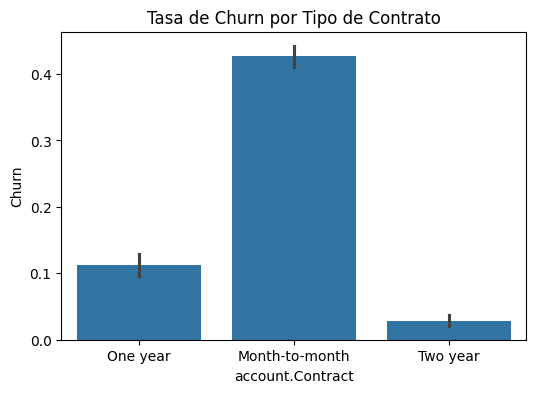

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.barplot(x="account.Contract", y="Churn", data=df)
plt.title("Tasa de Churn por Tipo de Contrato")
plt.show()

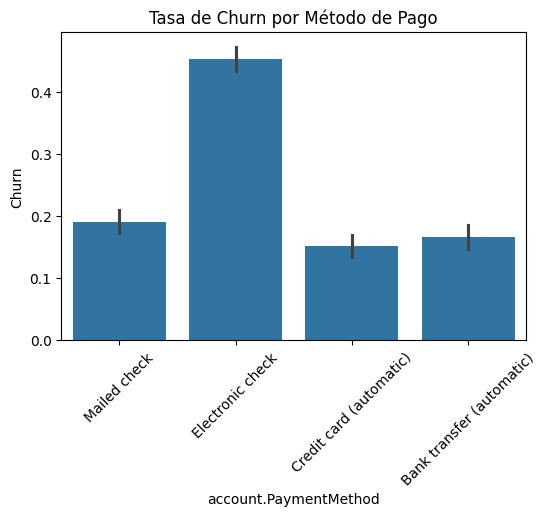

In [ ]:
plt.figure(figsize=(6,4))
sns.barplot(x="account.PaymentMethod", y="Churn", data=df)
plt.xticks(rotation=45)
plt.title("Tasa de Churn por Método de Pago")
plt.show()

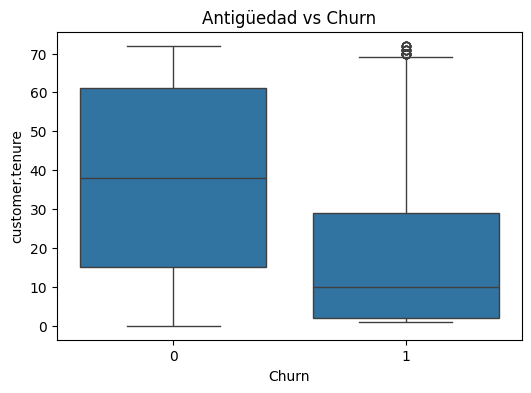

In [ ]:
plt.figure(figsize=(6,4))
sns.boxplot(x="Churn", y="customer.tenure", data=df)
plt.title("Antigüedad vs Churn")
plt.show()

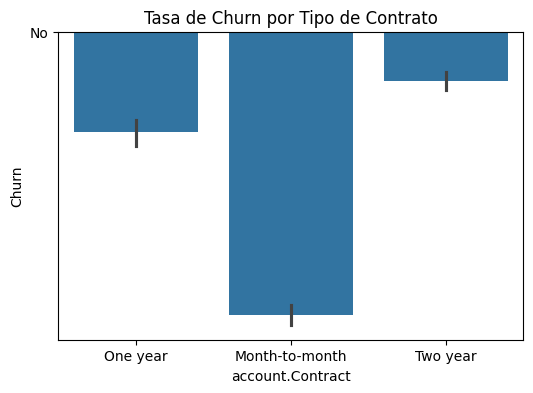

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.barplot(x="account.Contract", y="Churn", data=df)
plt.title("Tasa de Churn por Tipo de Contrato")
plt.show()

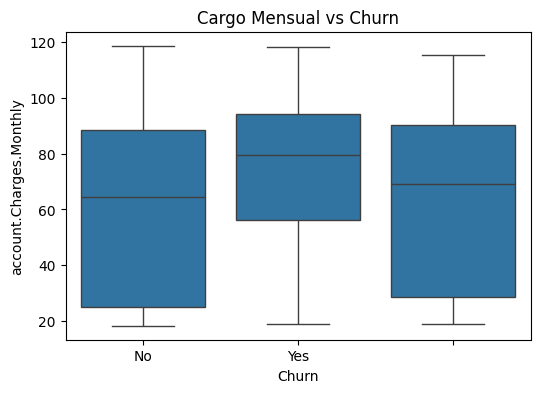

In [3]:
plt.figure(figsize=(6,4))
sns.boxplot(x="Churn", y="account.Charges.Monthly", data=df)
plt.title("Cargo Mensual vs Churn")
plt.show()

Informe Final — Análisis de Evasión (Churn) Telecom X
**Introducción**

El objetivo de este análisis es comprender los factores que influyen en la evasión de clientes (Churn) en Telecom X. La evasión representa un problema crítico para empresas de telecomunicaciones, ya que adquirir nuevos clientes suele ser más costoso que retener los existentes.

Se trabajó con una base de 7.043 clientes que incluye variables demográficas, tipo de contrato, método de pago, servicios contratados y cargos asociados.

**Limpieza y Tratamiento de Datos**

Se realizaron los siguientes pasos:

- Carga de datos desde la API en formato JSON.

- Conversión a DataFrame de Pandas.

- Eliminación de 224 registros con churn vacío.

- Conversión de account.Charges.Total de tipo object a float.

- Reemplazo de 11 valores nulos por la mediana.

- Codificación de la variable Churn (0 = No, 1 = Yes).

- Verificación de duplicados y valores inconsistentes.

Dimensión final del dataset:
7.043 registros y 21 columnas.

**Análisis Exploratorio de Datos**
Tasa General de Churn

- Tasa de evasión:
26.5%

Esto indica que aproximadamente 1 de cada 4 clientes abandona el servicio.

**Contrato y Churn**

- Month-to-month presenta la tasa de churn más alta (~42%)

- Contratos de 1 año reducen significativamente la evasión

- Contratos de 2 años tienen la menor tasa (~3%)

Insight:
La duración del contrato es uno de los factores más determinantes.

**Método de Pago**

Electronic check presenta la tasa de churn más alta (~45%)

Pagos automáticos presentan menor evasión

Insight:
Los métodos automáticos parecen mejorar la retención.

**Antigüedad**

- Clientes que churn tienen en promedio mucha menor antigüedad.

- La evasión ocurre principalmente durante los primeros meses.

**Cargos Mensuales**

- Clientes que pagan cargos mensuales más altos tienden a churn con mayor frecuencia.

**Conclusiones e Insights**

- El churn se concentra en clientes nuevos.

- Los contratos mensuales son el principal factor de riesgo.

- Los cargos mensuales altos aumentan la probabilidad de evasión.

- El método de pago electrónico no automático está asociado a mayor churn.

- Clientes con contratos largos presentan alta retención.

- El churn no es aleatorio. Está asociado a patrones claros de comportamiento contractual y financiero.

**Recomendaciones Estratégicas**

1️⃣ Incentivar contratos de largo plazo

Descuentos por contratos anuales o bianuales.

2️⃣ Programas de fidelización temprana

Contacto activo en los primeros 3 meses.

3️⃣ Promover pagos automáticos

Bonificaciones por inscripción en débito automático.

4️⃣ Revisión de estructura de precios

Evaluar percepción de valor en planes más costosos.

5️⃣ Modelado predictivo

Implementar modelo de Machine Learning para predecir churn antes de que ocurra.